# 🌊 Satellite Correction - whacs Spectrum (Optional)

> **Inputs:**
> - Wave spectrum to be corrected in `.nc` format, located in the `inputs/` folder.
> - Satellite data in `.nc` format, also located in the `inputs/` folder.
> - *Optional:* Wave buoy data for validating the satellite-based correction.
>
> **⚠️NOTE:** Instructions for downloading the satellite data are available at:  
> https://github.com/javitausia/CalValWaves
>
> **Outputs:**
> - Satellite-corrected wave spectrum in `.nc` format, saved in the `inputs/` folder.  
>   This file can be used either for Super-Point construction (if needed) or directly as input for BinWaves.



---

#### Before You Start

Make sure you have:

- Installed the latest version of `bluemath-tk`:  
  ```bash
  pip install bluemath-tk

- **BlueMath Toolkit Repository**:  [https://github.com/GeoOcean/BlueMath_tk.git](https://github.com/GeoOcean/BlueMath_tk.git)

Before continuing, ensure you have **created and activated a Python environment**.

*** Other Required Packages ***
- `wavespectra` 
- `cartophy`
 
---

This Jupyter Notebook is an alternative step to correct whacs or other hindcast data with Satellite information. The corrected spectra can be use: 

1. Create the SuperPoint (Cagigal et al., 2023)
2. As a input to teh BinWaves Reconstrcution Notebook.

---
<details open>


The hindcast significant wave height data can be calibrated using both buoy and satellite significant height of waves as the "good" measure, but the way we prefer to do it is calibrating first with the satellite data and validating with the buoy after the calibration. A description of what is done can be seen in this paper:

João Albuquerque, Jose A. A. Antolínez, Ana Rueda, Fernando J.Méndez, Giovanni Cocoa (November 2018). Directional correction of modeled sea and swell wave heights using satellite altimeter data. https://doi.org/10.1016/j.ocemod.2018.09.001

</details>

---


> **For more information check the BlueMath Repo:** 
>
> https://github.com/GeoOcean/BlueMath/blob/main/toolkit/waves/CalVal_Carolinas.ipynb

In [2]:
import xarray as xr
import pandas as pd
import numpy as np
import os
import os.path as op
from numpy import atan2
import wavespectra

In [3]:
seapoint_to_sample = 1904108
# buoy_coordinates= Lon: -74.839°, Lat: 36.612°
# WHACS Station Coordinates Lon: -74.8125°, Lat: 36.625°
station_lat=35.010
station_lon=-75.454
p_data = op.join(os.getcwd())
output_folder = op.join(p_data, 'outputs/41025_spec_WHACS.nc')

In [4]:
Hswell1 = xr.open_dataset("../inputs/WHACS/north_carolina_phs1_WHACS.nc").phs1.sel(
    seapoint=seapoint_to_sample
)
Hs = xr.open_dataset("../inputs/WHACS/north_carolina_hs_WHACS.nc").hs.sel(
    seapoint=seapoint_to_sample, time=Hswell1.time
)
Dp = xr.open_dataset("../inputs/WHACS/north_carolina_dp_WHACS.nc").dp.sel(
    seapoint=seapoint_to_sample, time=Hswell1.time
)
fp = xr.open_dataset("../inputs/WHACS/north_carolina_fp_WHACS.nc").fp.sel(
    seapoint=seapoint_to_sample, time=Hswell1.time
)
DirM = xr.open_dataset("../inputs/WHACS/north_carolina_dir_WHACS.nc").dir.sel(
    seapoint=seapoint_to_sample, time=Hswell1.time
)
Hsea = xr.open_dataset("../inputs/WHACS/north_carolina_phs0_WHACS.nc").phs0.sel(
    seapoint=seapoint_to_sample, time=Hswell1.time    
)

Hswell2 = xr.open_dataset("../inputs/WHACS/north_carolina_phs2_WHACS.nc").phs2.sel(
    seapoint=seapoint_to_sample, time=Hswell1.time
)
Hswell3 = xr.open_dataset("../inputs/WHACS/north_carolina_phs3_WHACS.nc").phs3.sel(
    seapoint=seapoint_to_sample, time=Hswell1.time
)
Dirsea = xr.open_dataset("../inputs/WHACS/north_carolina_pdp0_WHACS.nc").pdp0.sel(
    seapoint=seapoint_to_sample, time=Hswell1.time
)
Dirswell1 = xr.open_dataset("../inputs/WHACS/north_carolina_pdp1_WHACS.nc").pdp1.sel(
    seapoint=seapoint_to_sample, time=Hswell1.time
)
Dirswell2 = xr.open_dataset("../inputs/WHACS/north_carolina_pdp2_WHACS.nc").pdp2.sel(
    seapoint=seapoint_to_sample, time=Hswell1.time
)
Dirswell3 = xr.open_dataset("../inputs/WHACS/north_carolina_pdp3_WHACS.nc").pdp3.sel(
    seapoint=seapoint_to_sample, time= Hswell1.time   
)


In [5]:
csiro = pd.DataFrame({
    'Hs':Hs.values,
    'Dm':Dp.values,
    'Tp':1/fp.values,
    'DirM':DirM.values,
    'Hsea': Hsea.values,
    'Hswell1': Hswell1.values,
    'Hswell2': Hswell2.values,
    'Hswell3': Hswell3.values,
    'Dirsea': Dirsea.values,
    'Dirswell1': Dirswell1.values,
    'Dirswell2': Dirswell2.values,
    'Dirswell3': Dirswell3.values,
}, index=pd.to_datetime(Hs.time.values))

# csiro.index = csiro.index.round('H')
lat = float(station_lat)
lon = float(station_lon)
csiro_lon, csiro_lat = lon, lat
csiro

,Hs,Dm,Tp,DirM,Hsea,Hswell1,Hswell2,Hswell3,Dirsea,Dirswell1,Dirswell2,Dirswell3
1979-01-01 00:00:00,0.412,75.0,12.499999,71.300003,NaN,0.306,0.204,0.170,NaN,62.600002,74.900002,81.000000
1979-01-01 01:00:00,0.416,81.0,16.666666,71.599998,NaN,0.306,0.208,0.176,NaN,62.400002,74.900002,81.000000
1979-01-01 02:00:00,0.420,81.0,16.666666,71.900002,NaN,0.304,0.208,0.186,NaN,62.100002,74.900002,81.099998
1979-01-01 03:00:00,0.424,81.0,16.666666,72.200005,NaN,0.302,0.208,0.196,NaN,61.799999,74.900002,81.099998
1979-01-01 04:00:00,0.426,81.0,16.666666,72.599998,NaN,0.300,0.214,0.200,NaN,61.500000,81.099998,75.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 19:00:00,1.030,218.0,6.944444,222.000000,0.982,0.288,0.092,0.078,218.600006,103.599998,44.799999,79.500000
2023-12-31 20:00:00,1.056,218.0,6.896551,222.199997,1.008,0.292,0.082,0.076,218.500000,103.500000,45.100002,78.400002
2023-12-31 21:00:00,1.124,218.0,6.849315,222.400009,1.078,0.294,0.084,0.076,218.300003,103.300003,49.400002,74.900002
2023-12-31 22:00:00,1.204,218.0,6.711409,221.800003,1.160,0.298,0.082,0.078,219.500000,103.200005,47.700001,74.900002


In [6]:
buoy = (
    pd.read_pickle(
        f"../inputs/buoy_data/buoy_41025_bulk_parameters_nonzeros.pkl"
    )
    .rename(columns={"Hs_Buoy": "Hs_CAL"})
)
buoy = buoy.dropna(subset=['Hs_CAL'])
buoy['LATITUDE']=station_lat
buoy['LONGITUDE']=station_lon
buoy

# # Remove rows where Hs_CAL = 0 and save to new file with Hs_Buoy column name
# buoy_nonzero = buoy[buoy['Hs_CAL'] >= 0.2].copy()
# buoy_nonzero = buoy_nonzero.rename(columns={"Hs_CAL": "Hs_Buoy"})
# buoy_nonzero.to_pickle("inputs/buoy_data/buoy_41025_bulk_parameters_nonzeros.pkl")


,Hs_CAL,Tm_Buoy,Tp_Buoy,Dir_Buoy,Spr_Buoy,LATITUDE,LONGITUDE
datetime,,,,,,,
2003-03-28 20:00:00,1.850,4.930,6.250,NaN,NaN,35.01,-75.454
2003-03-28 21:00:00,1.960,5.270,6.250,NaN,NaN,35.01,-75.454
2003-03-28 22:00:00,2.020,5.390,7.140,NaN,NaN,35.01,-75.454
2003-03-28 23:00:00,2.090,5.420,7.140,NaN,NaN,35.01,-75.454
2003-03-29 00:00:00,2.010,5.560,7.140,NaN,NaN,35.01,-75.454
...,...,...,...,...,...,...,...
2024-12-31 19:00:00,1.450,4.560,6.905,153.0,NaN,35.01,-75.454
2024-12-31 20:00:00,1.410,4.565,5.610,154.5,NaN,35.01,-75.454
2024-12-31 21:00:00,1.360,4.485,4.760,175.0,NaN,35.01,-75.454


### Comparison Wave Buoy vs Raw whacs spectrum

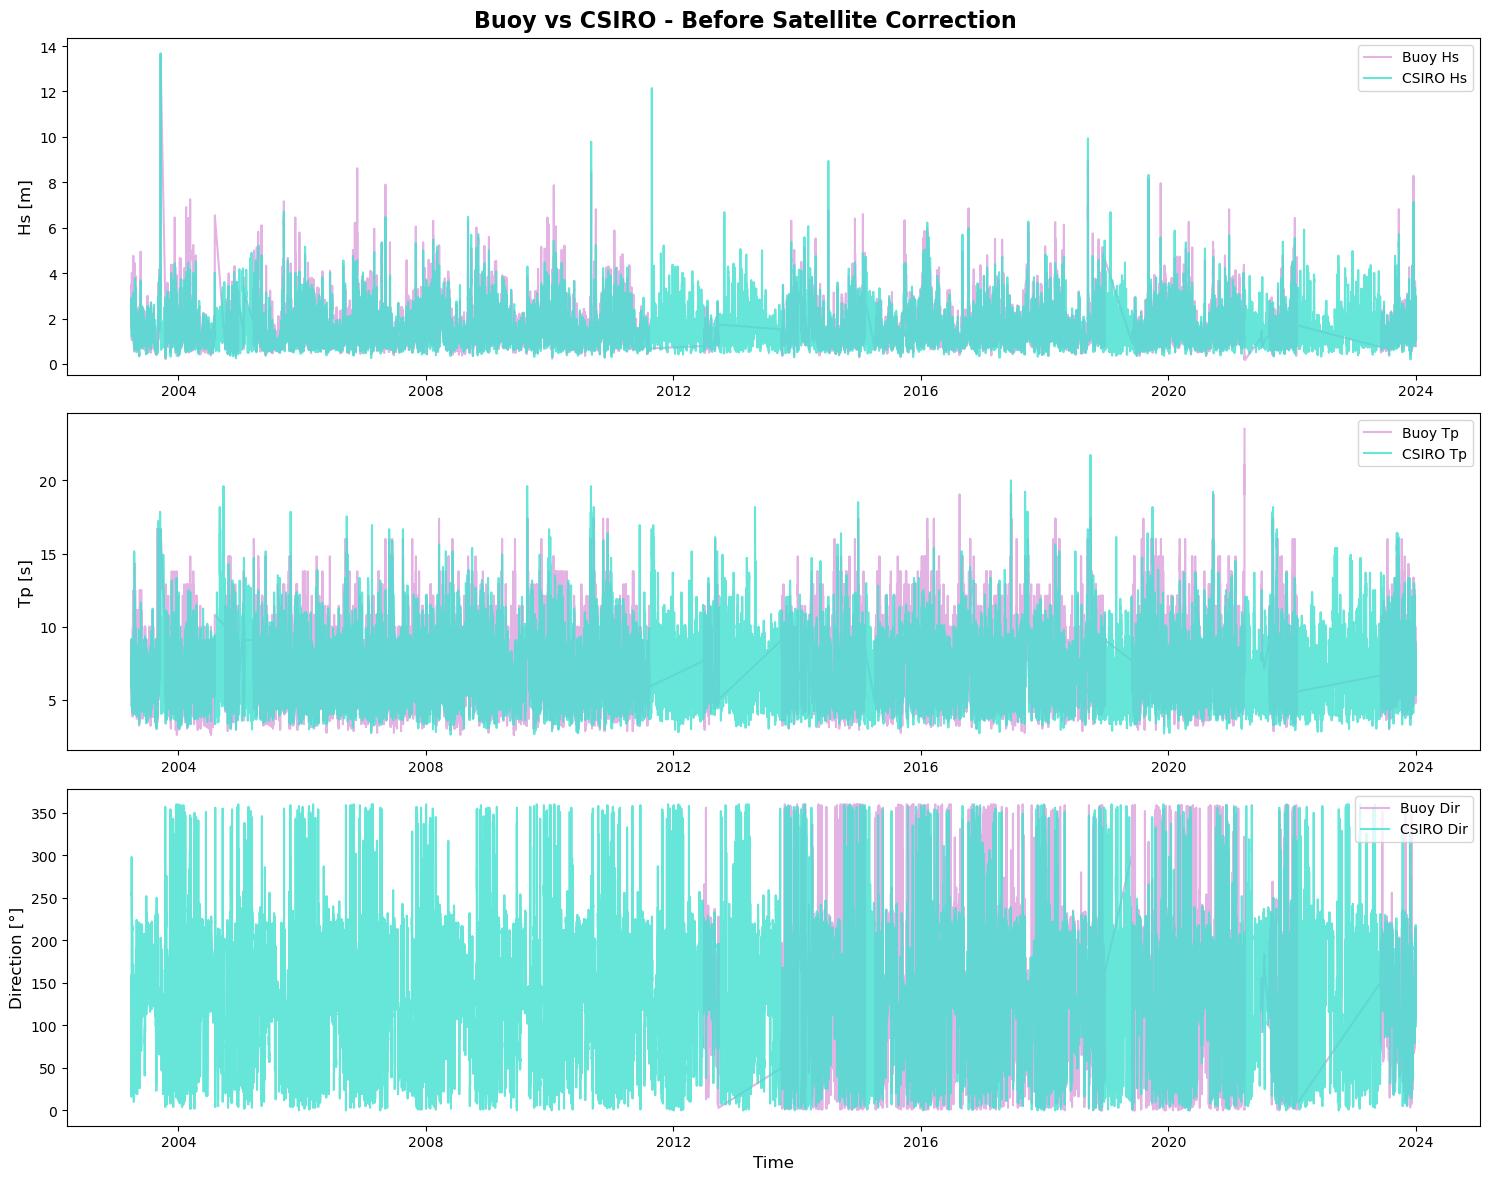

/tmp/ipykernel_4079207/1369460264.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


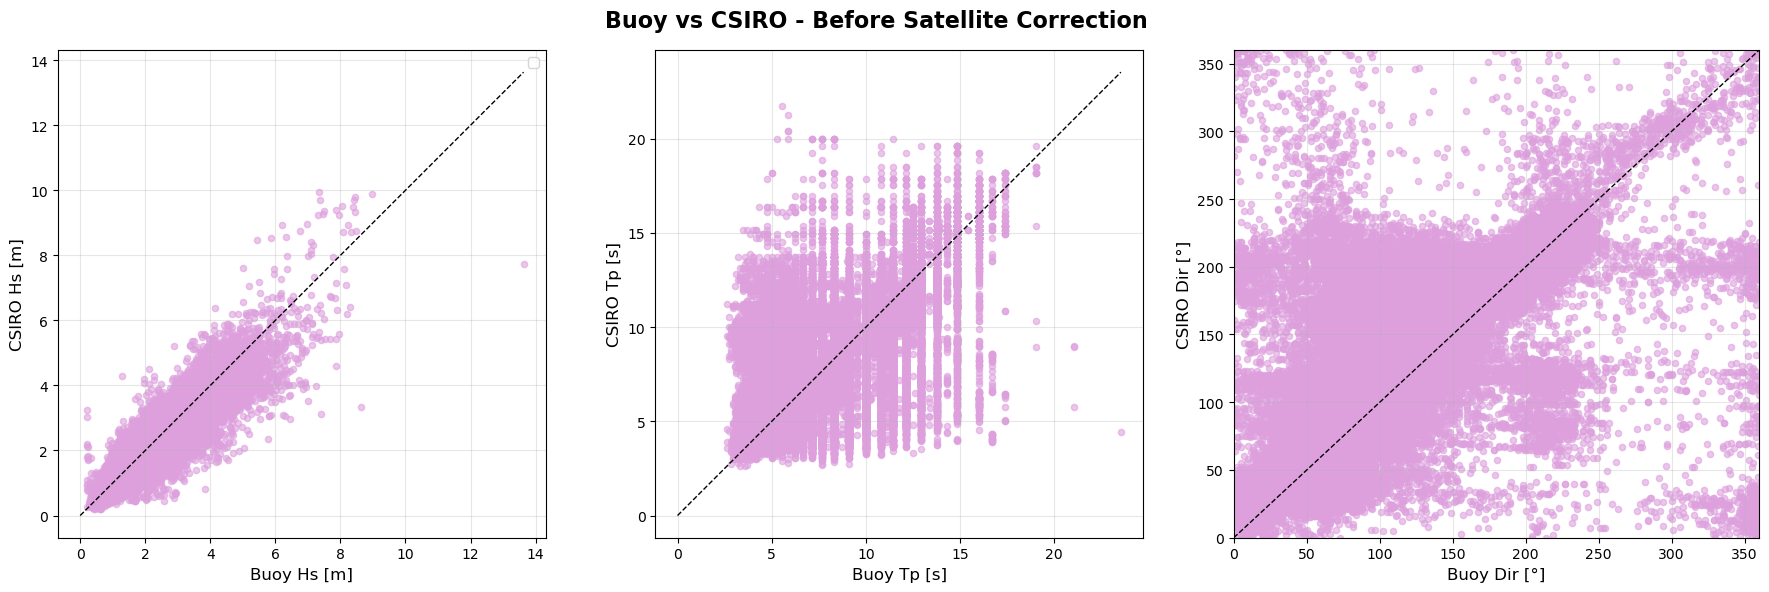

Data Statistics:
Common time period: 2003-03-28 20:00:00 to 2023-12-31 23:00:00
Number of common data points: 133828

Correlation coefficients:
Hs correlation: 0.921
Tp correlation: 0.628
Dir correlation: 0.685


In [7]:
# Plot comparison between buoy validation data and CSIRO data
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates

# Create time series plot
fig1, axes = plt.subplots(3, 1, figsize=(15, 12))
fig1.suptitle('Buoy vs CSIRO - Before Satellite Correction', fontsize=16, fontweight='bold')

# Find common time range
common_start = max(buoy.index.min(), csiro.index.min())
common_end = min(buoy.index.max(), csiro.index.max())

# Filter data to common time range
buoy_common = buoy[(buoy.index >= common_start) & (buoy.index <= common_end)]
csiro_common = csiro[(csiro.index >= common_start) & (csiro.index <= common_end)]

# Hs time series
axes[0].plot(buoy_common.index, buoy_common['Hs_CAL'], color='plum', label='Buoy Hs', linewidth=1.5, alpha=0.8)
axes[0].plot(csiro_common.index, csiro_common['Hs'], color='turquoise', label='CSIRO Hs', linewidth=1.5, alpha=0.8)
axes[0].set_ylabel('Hs [m]', fontsize=12)
axes[0].legend(fontsize=10)

# Tp time series
axes[1].plot(buoy_common.index, buoy_common['Tp_Buoy'], color='plum', label='Buoy Tp', linewidth=1.5, alpha=0.8)
axes[1].plot(csiro_common.index, csiro_common['Tp'], color='turquoise', label='CSIRO Tp', linewidth=1.5, alpha=0.8)
axes[1].set_ylabel('Tp [s]', fontsize=12)
axes[1].legend(fontsize=10)

# Dir time series
axes[2].plot(buoy_common.index, buoy_common['Dir_Buoy'], color='plum', label='Buoy Dir', linewidth=1.5, alpha=0.8)
axes[2].plot(csiro_common.index, csiro_common['Dm'], color='turquoise', label='CSIRO Dir', linewidth=1.5, alpha=0.8)
axes[2].set_ylabel('Direction [°]', fontsize=12)
axes[2].set_xlabel('Time', fontsize=12)
axes[2].legend(fontsize=10)
plt.tight_layout()
plt.show()

# Create scatter plots
fig2, axes = plt.subplots(1, 3, figsize=(18, 6))
fig2.suptitle('Buoy vs CSIRO - Before Satellite Correction', fontsize=16, fontweight='bold')

# Merge data on time index for scatter plots
merged_data = buoy_common.merge(csiro_common, left_index=True, right_index=True, how='inner')

# Hs scatter plot
axes[0].scatter(merged_data['Hs_CAL'], merged_data['Hs'], alpha=0.6, s=20, color='plum')
axes[0].plot([0, merged_data['Hs_CAL'].max()], [0, merged_data['Hs_CAL'].max()], 'k--', linewidth=1)
axes[0].set_xlabel('Buoy Hs [m]', fontsize=12)
axes[0].set_ylabel('CSIRO Hs [m]', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal')

# Tp scatter plot
axes[1].scatter(merged_data['Tp_Buoy'], merged_data['Tp'], alpha=0.6, s=20, color='plum')
axes[1].plot([0, merged_data['Tp_Buoy'].max()], [0, merged_data['Tp_Buoy'].max()], 'k--', linewidth=1)
axes[1].set_xlabel('Buoy Tp [s]', fontsize=12)
axes[1].set_ylabel('CSIRO Tp [s]', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect('equal')

# Dir scatter plot
axes[2].scatter(merged_data['Dir_Buoy'], merged_data['Dm'], alpha=0.6, s=20, color='plum')
axes[2].plot([0, 360], [0, 360], 'k--', linewidth=1)
axes[2].set_xlabel('Buoy Dir [°]', fontsize=12)
axes[2].set_ylabel('CSIRO Dir [°]', fontsize=12)
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim(0, 360)
axes[2].set_ylim(0, 360)

plt.tight_layout()
plt.show()

# Print some statistics
print("Data Statistics:")
print(f"Common time period: {common_start} to {common_end}")
print(f"Number of common data points: {len(merged_data)}")
print("\nCorrelation coefficients:")
print(f"Hs correlation: {merged_data['Hs_CAL'].corr(merged_data['Hs']):.3f}")
print(f"Tp correlation: {merged_data['Tp_Buoy'].corr(merged_data['Tp']):.3f}")
print(f"Dir correlation: {merged_data['Dir_Buoy'].corr(merged_data['DirM']):.3f}")

> ⚠️ **NOTE:** A smaller radius (0.2 degrees) was selected for this correction—compared to the 1-degree radius used in Albuquerque et al., 2018—due to abrupt depth changes around the WHACS point.


In [ ]:
# from bluemath_tk.waves.calibration import CalVal, process_imos_satellite_data


# satellite_raw = xr.open_dataset("inputs/satellite_dataset_carolinas.nc")[
#     [
#         "SWH_KU_quality_control",
#         "SWH_KA_quality_control",
#         "SWH_KU_CAL",
#         "SWH_KA_CAL",
#         "BOT_DEPTH",
#     ]
# ].to_dataframe()
# satellite_processed = process_imos_satellite_data(
#     satellite_df=satellite_raw,
#     ini_lat=station_lat-10,
#     end_lat=station_lat+10,
#     ini_lon=station_lon-10,
#     end_lon=station_lon+10,
#     depth_threshold=-100,
# )
# # satellite_processed = process_imos_satellite_data(
# #     satellite_df=satellite_raw,
# #     ini_lat=station_lat-.5,
# #     end_lat=station_lat+.5,
# #     ini_lon=station_lon-.5,
# #     end_lon=station_lon+.5,
# #     depth_threshold=-40,
# # )


# satellite_processed

In [8]:
from bluemath_tk.waves.calibration import CalVal

In [9]:
calval = CalVal()
calval

In [10]:
# Build a mask that includes ALL sea and swell columns
whacs_hindcast_data = csiro
cols = ['Hsea','Dirsea'] + [c for c in whacs_hindcast_data.columns if c.lower().startswith('hswell')]
cols += [c for c in whacs_hindcast_data.columns if c.lower().startswith('dirswell')]

mask = whacs_hindcast_data[cols].apply(np.isfinite).all(axis=1)
whacs_clean = whacs_hindcast_data.loc[mask].copy()

print("NaNs left in required columns:", (~np.isfinite(whacs_clean[cols])).sum().sum())


NaNs left in required columns: 0


/vols/abedul/home/grupos/geocean/montanoj/Bluemath_tk_fork/BlueMath_tk/bluemath_tk/waves/calibration.py:318: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if direcs[i] < 0:
/vols/abedul/home/grupos/geocean/montanoj/Bluemath_tk_fork/BlueMath_tk/bluemath_tk/waves/calibration.py:320: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if direcs[i] > 0 and waves[i] > 0:
/vols/abedul/home/grupos/geocean/montanoj/Bluemath_tk_fork/BlueMath_tk/bluemath_tk/waves/calibration.py:322: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consiste

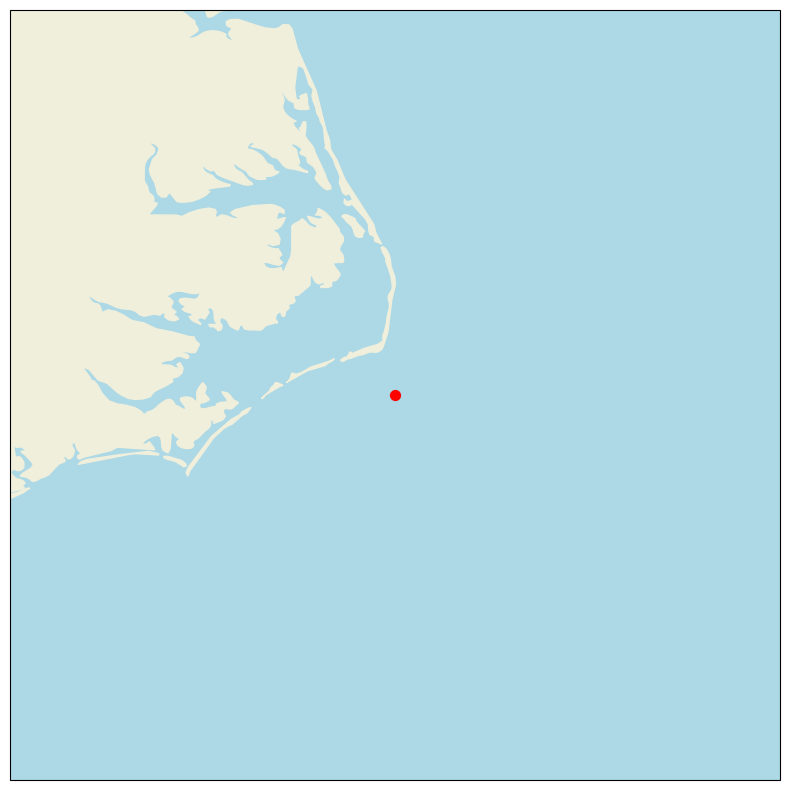

In [11]:
calval.fit(
    data=whacs_clean,
    data_longitude=csiro_lon,
    data_latitude=csiro_lat,
    data_to_calibrate=buoy,
    max_time_diff=1,
)

In [12]:
calval.calibration_params

{'sea_correction': {0: np.float64(0.9671950802683142),
  1: np.float64(0.96522877155207),
  2: np.float64(1.0228976570093817),
  3: np.float64(1.0588207244703582),
  4: np.float64(1.0861503453720511),
  5: np.float64(1.0958835536391387),
  6: np.float64(1.0820766715724581),
  7: np.float64(1.0822334990903268),
  8: np.float64(0.9138842000581745),
  9: np.float64(0.9524822488695193),
  10: np.float64(1.0107816515272536),
  11: np.float64(1.0029803685488121),
  12: np.float64(0.9682267665478237),
  13: np.float64(0.9744008271271632),
  14: np.float64(0.9896997214099059),
  15: np.float64(0.9397656714082768)},
 'swell_correction': {0: np.float64(0.9972476840503122),
  1: np.float64(1.132504656834566),
  2: np.float64(1.2247187372002069),
  3: np.float64(1.0248054940458766),
  4: np.float64(0.9779383549768287),
  5: np.float64(0.990896041434849),
  6: np.float64(1.011688682406222),
  7: np.float64(0.9145838220412352),
  8: np.float64(0.9219869553332084),
  9: np.float64(0.9311779875613395)

/vols/abedul/home/grupos/geocean/montanoj/Bluemath_tk_fork/BlueMath_tk/bluemath_tk/core/plotting/scatter.py:130: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x1, y1, z = x[idx], y[idx], z[idx]
/vols/abedul/home/grupos/geocean/montanoj/Bluemath_tk_fork/BlueMath_tk/bluemath_tk/waves/calibration.py:750: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax5.set_xticklabels(["N", "NE", "E", "SE", "S", "SW", "W", "NW"])
/vols/abedul/home/grupos/geocean/montanoj/Bluemath_tk_fork/BlueMath_tk/bluemath_tk/core/plotting/scatter.py:130: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value b

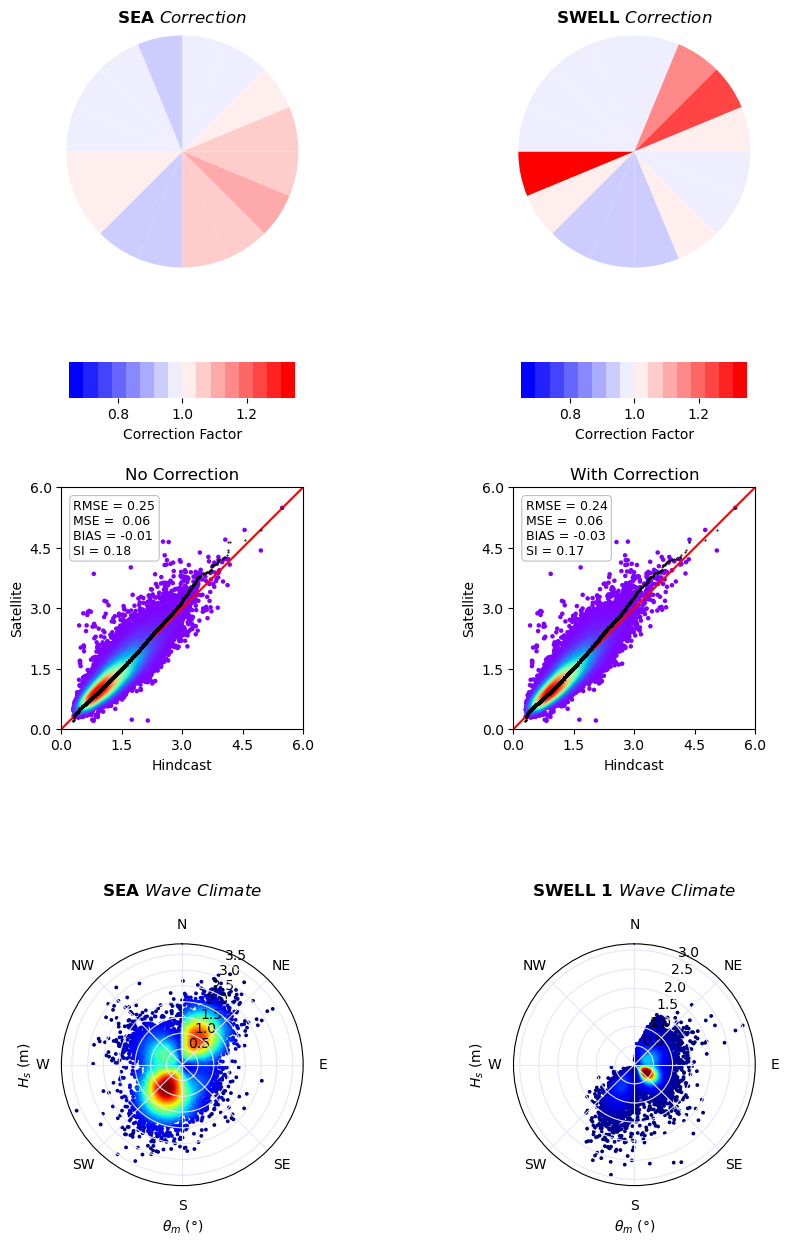

In [13]:
calval.plot_calibration_results();

In [14]:
corrected_csiro = calval.correct(data=csiro)
corrected_csiro

,Hs,Dm,Tp,DirM,Hsea,Hswell1,Hswell2,Hswell3,Dirsea,Dirswell1,Dirswell2,Dirswell3,Hs_CORR
1979-01-01 00:00:00,0.412,75.0,12.499999,71.300003,NaN,0.140448,0.043706,0.030352,NaN,62.600002,74.900002,81.000000,NaN
1979-01-01 01:00:00,0.416,81.0,16.666666,71.599998,NaN,0.140448,0.045437,0.032532,NaN,62.400002,74.900002,81.000000,NaN
1979-01-01 02:00:00,0.420,81.0,16.666666,71.900002,NaN,0.138618,0.045437,0.036334,NaN,62.100002,74.900002,81.099998,NaN
1979-01-01 03:00:00,0.424,81.0,16.666666,72.200005,NaN,0.136800,0.045437,0.040345,NaN,61.799999,74.900002,81.099998,NaN
1979-01-01 04:00:00,0.426,81.0,16.666666,72.599998,NaN,0.134994,0.048096,0.042009,NaN,61.500000,81.099998,75.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 19:00:00,1.030,218.0,6.944444,222.000000,0.874856,0.079325,0.010856,0.006390,218.600006,103.599998,44.799999,79.500000,0.985610
2023-12-31 20:00:00,1.056,218.0,6.896551,222.199997,0.921796,0.081543,0.010086,0.006066,218.500000,103.500000,45.100002,78.400002,1.009699
2023-12-31 21:00:00,1.124,218.0,6.849315,222.400009,1.054269,0.082664,0.010584,0.006066,218.300003,103.300003,49.400002,74.900002,1.074050
2023-12-31 22:00:00,1.204,218.0,6.711409,221.800003,1.220759,0.084929,0.010086,0.006390,219.500000,103.200005,47.700001,74.900002,1.149853


In [16]:
sprsea = xr.open_dataset("../inputs/WHACS/north_carolina_pspr0_WHACS.nc").pspr0.sel(
    seapoint=seapoint_to_sample, time= corrected_csiro.index.values
)
sprswell1 = xr.open_dataset("../inputs/WHACS/north_carolina_pspr1_WHACS.nc").pspr1.sel(
    seapoint=seapoint_to_sample, time= corrected_csiro.index.values 
)
sprswell2 = xr.open_dataset("../inputs/WHACS/north_carolina_pspr2_WHACS.nc").pspr2.sel(
    seapoint=seapoint_to_sample, time= corrected_csiro.index.values  
)
sprswell3 = xr.open_dataset("../inputs/WHACS/north_carolina_pspr3_WHACS.nc").pspr3.sel(
    seapoint=seapoint_to_sample, time= corrected_csiro.index.values
)

tpsea = xr.open_dataset("../inputs/WHACS/north_carolina_ptp0_WHACS.nc").ptp0.sel(
    seapoint=seapoint_to_sample, time= corrected_csiro.index.values
)

tpswell1 = xr.open_dataset("../inputs/WHACS/north_carolina_ptp1_WHACS.nc").ptp1.sel(
    seapoint=seapoint_to_sample, time= corrected_csiro.index.values
)

tpswell2 = xr.open_dataset("../inputs/WHACS/north_carolina_ptp2_WHACS.nc").ptp2.sel(
    seapoint=seapoint_to_sample, time= corrected_csiro.index.values
)

tpswell3 = xr.open_dataset("../inputs/WHACS/north_carolina_ptp3_WHACS.nc").ptp3.sel(
    seapoint=seapoint_to_sample, time= corrected_csiro.index.values
)

In [17]:
corrected_csiro['Tpsea'] = tpsea
corrected_csiro['Tpswell1'] = tpswell1
corrected_csiro['Tpswell2'] = tpswell2
corrected_csiro['Tpswell3'] = tpswell3
corrected_csiro['Sprsea'] = sprsea
corrected_csiro['Sprswell1'] = sprswell1
corrected_csiro['Sprswell2'] = sprswell2
corrected_csiro['Sprswell3'] = sprswell3


In [18]:
corrected_csiro

,Hs,Dm,Tp,DirM,Hsea,Hswell1,Hswell2,Hswell3,Dirsea,Dirswell1,...,Dirswell3,Hs_CORR,Tpsea,Tpswell1,Tpswell2,Tpswell3,Sprsea,Sprswell1,Sprswell2,Sprswell3
1979-01-01 00:00:00,0.412,75.0,12.499999,71.300003,NaN,0.140448,0.043706,0.030352,NaN,62.600002,...,81.000000,NaN,NaN,7.450000,12.429999,17.020000,NaN,18.800001,11.800000,11.0
1979-01-01 01:00:00,0.416,81.0,16.666666,71.599998,NaN,0.140448,0.045437,0.032532,NaN,62.400002,...,81.000000,NaN,NaN,7.440000,12.420000,16.910000,NaN,18.500000,11.900001,10.8
1979-01-01 02:00:00,0.420,81.0,16.666666,71.900002,NaN,0.138618,0.045437,0.036334,NaN,62.100002,...,81.099998,NaN,NaN,7.440000,12.410000,16.809999,NaN,18.400000,12.000000,10.7
1979-01-01 03:00:00,0.424,81.0,16.666666,72.200005,NaN,0.136800,0.045437,0.040345,NaN,61.799999,...,81.099998,NaN,NaN,7.440000,12.400000,16.740000,NaN,18.400000,12.000000,10.7
1979-01-01 04:00:00,0.426,81.0,16.666666,72.599998,NaN,0.134994,0.048096,0.042009,NaN,61.500000,...,75.000000,NaN,NaN,7.450000,16.619999,12.389999,NaN,18.800001,10.600000,12.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 19:00:00,1.030,218.0,6.944444,222.000000,0.874856,0.079325,0.010856,0.006390,218.600006,103.599998,...,79.500000,0.985610,6.92,10.420000,7.940000,14.719999,22.4,12.000000,18.800001,13.6
2023-12-31 20:00:00,1.056,218.0,6.896551,222.199997,0.921796,0.081543,0.010086,0.006066,218.500000,103.500000,...,78.400002,1.009699,6.88,10.380000,8.099999,14.259999,22.0,11.900001,10.200000,12.1
2023-12-31 21:00:00,1.124,218.0,6.849315,222.400009,1.054269,0.082664,0.010584,0.006066,218.300003,103.300003,...,74.900002,1.074050,6.83,10.349999,8.380000,14.719999,22.4,11.500000,10.700000,11.1
2023-12-31 22:00:00,1.204,218.0,6.711409,221.800003,1.220759,0.084929,0.010086,0.006390,219.500000,103.200005,...,74.900002,1.149853,6.66,10.330000,8.420000,14.670000,23.5,11.500000,9.700000,11.1


In [19]:
# freq = np.arange(0.03, 0.401, 0.01)
# dir = np.arange(0, 360, 12)
# freq = np.array([0.035,      0.03848704, 0.0423215,  0.04653798, 0.05117455, 0.05627306,
#  0.06187953, 0.06804458, 0.07482385, 0.08227853, 0.09047592, 0.09949002,
#  0.10940219, 0.12030191, 0.13228757, 0.14546735, 0.15996023, 0.17589704,
#  0.19342162, 0.21269218, 0.23388266, 0.25718434, 0.28280756, 0.31098362,
#  0.34196685, 0.37603694, 0.41350142, 0.45469848, 0.5       ])
# dir = np.arange(0, 360, 5)
dir = np.array([7.5, 22.5, 37.5, 52.5, 67.5, 82.5, 97.5, 112.5, 127.5, 142.5, 157.5, 172.5, 187.5, 202.5, 217.5, 232.5, 247.5, 262.5, 277.5, 292.5, 307.5, 322.5, 337.5, 352.5])

freq = np.array([0.035, 0.03848704, 0.0423215, 0.04653798, 0.05117455, 0.05627306, 0.06187953, 0.06804458, 0.07482385, 0.08227853, 0.09047592, 0.09949002, 0.10940219, 0.12030191, 0.13228757, 0.14546735, 0.15996023, 0.17589704, 0.19342162, 0.21269218, 0.23388266, 0.25718434, 0.28280756, 0.31098362, 0.34196685, 0.37603694, 0.41350142, 0.45469848, 0.5])

In [20]:
time_to_sample = slice(corrected_csiro.index.values) 
seapoint_to_sample = seapoint_to_sample

# Map the DataFrame columns to xarray DataArrays for each partition
# Assuming corrected_csiro has columns: Hsea, Hswell1, Hswell2, Hswell3
# and corresponding Tpsea, Tpswell1, etc. and Dirsea, Dirswell1, etc.

# Define mapping for each partition (0=sea, 1-3=swell)
partition_names = {
    0: 'sea',
    1: 'swell1', 
    2: 'swell2',
    3: 'swell3'
}

whacs_sample = xr.Dataset(
    {
        "hs": xr.concat(
            [
                xr.DataArray(
                    corrected_csiro[f"Hsea" if i == 0 else f"Hswell{i}"].values,
                    dims=["time"],
                    coords={"time": corrected_csiro.index}
                )
                .expand_dims({"part": [i]})
                for i in range(4)
            ],
            dim="part",
        ),
        "tp": xr.concat(
            [
                xr.DataArray(
                    corrected_csiro[f"Tpsea" if i == 0 else f"Tpswell{i}"].values,
                    dims=["time"],
                    coords={"time": corrected_csiro.index}
                ).expand_dims({"part": [i]})
                for i in range(4)
            ],
            dim="part",
        ),
        "dp": xr.concat(
            [
                xr.DataArray(
                    corrected_csiro[f"Dirsea" if i == 0 else f"Dirswell{i}"].values,
                    dims=["time"],
                    coords={"time": corrected_csiro.index}
                ).expand_dims({"part": [i]})
                for i in range(4)
            ],
            dim="part",
        ),
        "spr": xr.concat(
            [
                xr.DataArray(
                    corrected_csiro[f"Sprsea" if i == 0 else f"Sprswell{i}"].values,
                    dims=["time"],
                    coords={"time": corrected_csiro.index}
                ).expand_dims({"part": [i]})
                for i in range(4)
            ],
            dim="part",
        ),
    }
)
whacs_sample

<xarray.Dataset> Size: 35MB
Dimensions:  (part: 4, time: 393720)
Coordinates:
  * part     (part) int64 32B 0 1 2 3
  * time     (time) datetime64[ns] 3MB 1979-01-01 ... 2023-12-31T23:00:00
Data variables:
    hs       (part, time) float64 13MB nan nan nan ... 0.006066 0.00639 0.003119
    tp       (part, time) float32 6MB nan nan nan nan ... 14.26 14.72 14.67 4.67
    dp       (part, time) float32 6MB nan nan nan nan nan ... 78.4 74.9 74.9 3.0
    spr      (part, time) float32 6MB nan nan nan nan nan ... 12.1 11.1 11.1 6.7

In [21]:
from wavespectra.construct import construct_partition
full_spec = construct_partition(
    freq_name="jonswap",
    freq_kwargs={
        "freq": freq,
        "fp": 1 / whacs_sample.tp,
        "hs": np.sqrt(whacs_sample.hs),
    },
    dir_name="cartwright",
    dir_kwargs={
        "dir": dir,
        "dm": whacs_sample.dp,
        "dspr": whacs_sample.spr,
    },
)
full_spec

<xarray.DataArray (part: 4, time: 393720, freq: 29, dir: 24)> Size: 9GB
array([[[[0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
          0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
         [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
          0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
         [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
          0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
         ...,
         [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
          0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
         [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
          0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
         [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
          0.00000000e+000, 0.00000000e+000, 0.00000000e+000]],

        [[0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
          0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
         [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
          0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
         [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
          0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
...
          1.92417441e-034, 1.11661065e-026, 9.99004176e-021],
         [2.27700920e-016, 6.15678312e-013, 1.77791034e-010, ...,
          1.19712271e-034, 6.94697923e-027, 6.21529201e-021],
         [1.41650771e-016, 3.83008148e-013, 1.10602263e-010, ...,
          7.44719673e-035, 4.32165565e-027, 3.86647936e-021]],

        [[0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
          0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
         [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
          0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
         [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
          0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
         ...,
         [4.83700279e-006, 8.83461549e-008, 9.44280007e-012, ...,
          5.39496563e-014, 4.28349650e-009, 1.78433516e-006],
         [3.09516163e-006, 5.65320388e-008, 6.04237661e-012, ...,
          3.45219785e-014, 2.74097713e-009, 1.14178262e-006],
         [1.96286401e-006, 3.58510208e-008, 3.83190443e-012, ...,
          2.18928628e-014, 1.73825021e-009, 7.24086260e-007]]]],
      shape=(4, 393720, 29, 24))
Coordinates:
  * part     (part) int64 32B 0 1 2 3
  * time     (time) datetime64[ns] 3MB 1979-01-01 ... 2023-12-31T23:00:00
  * freq     (freq) float64 232B 0.035 0.03849 0.04232 ... 0.4135 0.4547 0.5
  * dir      (dir) float64 192B 7.5 22.5 37.5 52.5 ... 307.5 322.5 337.5 352.5

Text(0, 0.5, 'CSIRO Corrected Hs [m]')

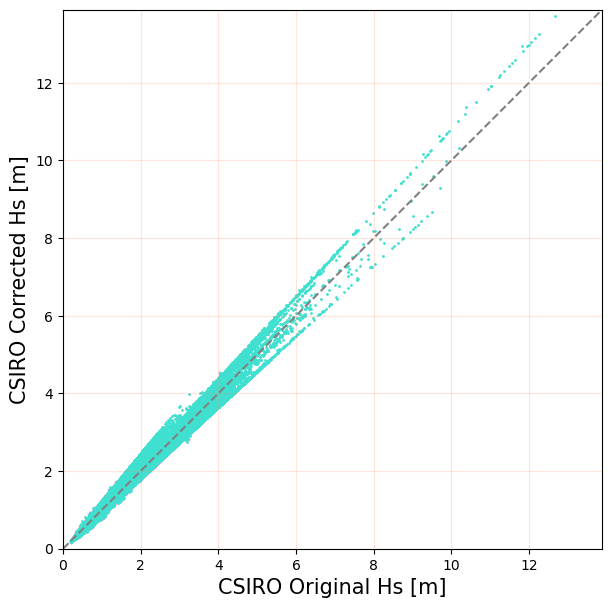

In [22]:
# Fix the subplot creation
fig, ax = plt.subplots(figsize=[20, 7])

ax.scatter(corrected_csiro.Hs, corrected_csiro.Hs_CORR, c='plum', s=3)
ax.scatter(corrected_csiro.Hs, full_spec.sum("part").spec.hs(), c='turquoise', s=1)
ax.plot([0, np.nanmax(corrected_csiro.Hs)+.2], [0, np.nanmax(corrected_csiro.Hs)+.2], '--', color='gray')
ax.set_aspect('equal')
ax.set_xlim([0, np.nanmax(corrected_csiro.Hs)+.2])
ax.set_ylim([0, np.nanmax(corrected_csiro.Hs)+.2])
ax.grid(color='coral', alpha=.2)
ax.set_xlabel('CSIRO Original Hs [m]', fontsize=15)
ax.set_ylabel('CSIRO Corrected Hs [m]', fontsize=15)

In [23]:
# Convert full_spec time to pandas DatetimeIndex
spec_times = pd.DatetimeIndex(full_spec.time.values)

# Find intersection with buoy times
common_times = buoy.index.intersection(spec_times)
print(f"Common timestamps: {len(common_times)}")

# Filter both to common times
buoy_common = buoy.loc[common_times]
csiro_common = full_spec.sel(time=common_times)

print(f"Buoy shape: {buoy_common.shape}")
print(f"Spec shape: {csiro_common.sizes}")

Common timestamps: 133828
Buoy shape: (133828, 7)
Spec shape: Frozen({'part': 4, 'time': 133828, 'freq': 29, 'dir': 24})


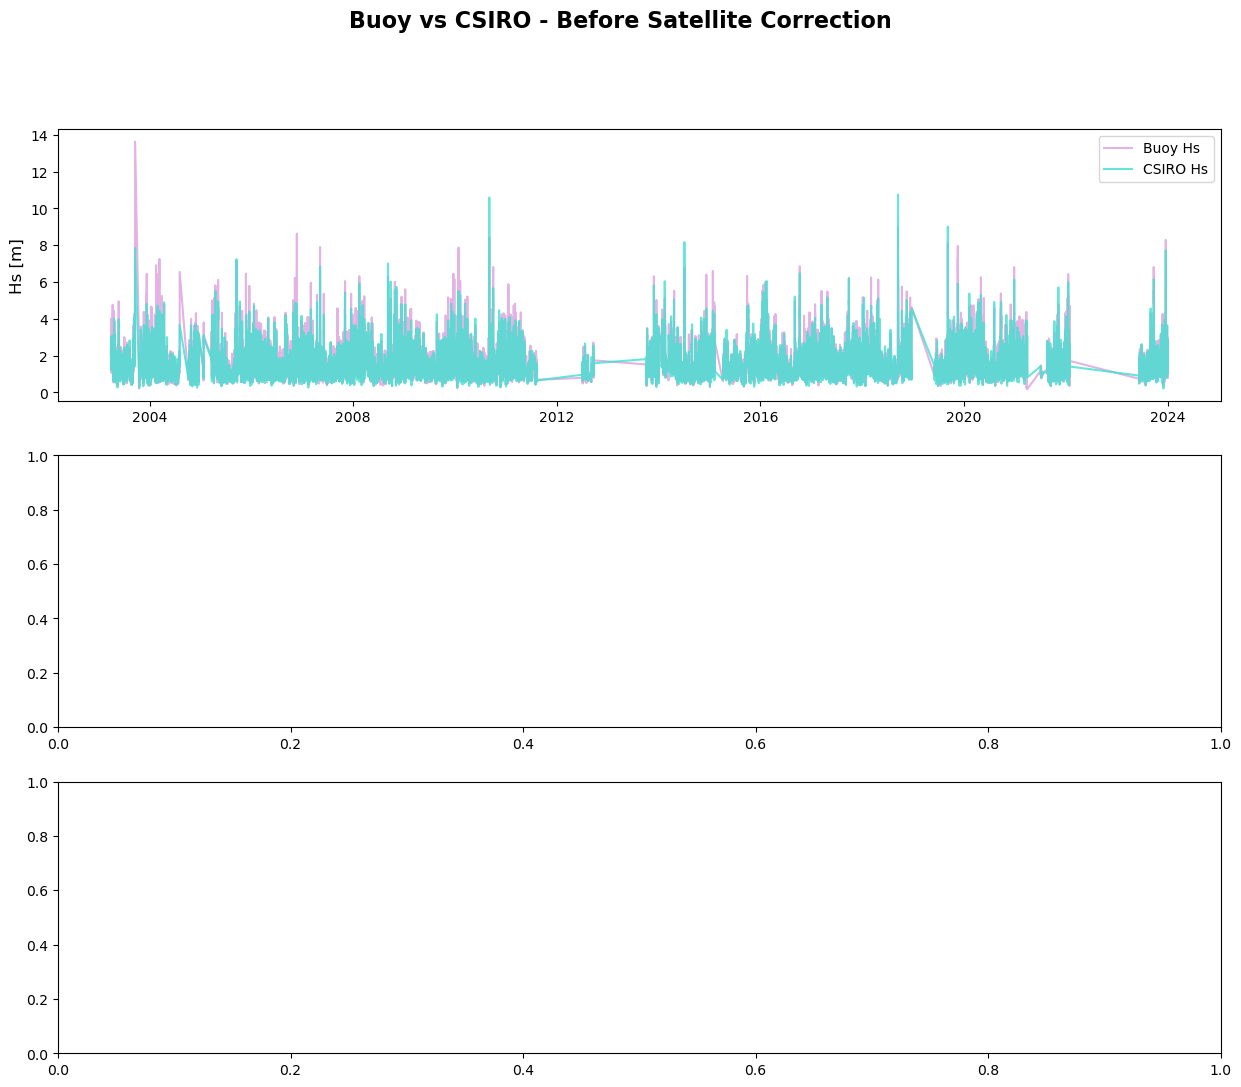

In [24]:
# Create time series plot
fig1, axes = plt.subplots(3, 1, figsize=(15, 12))
fig1.suptitle('Buoy vs CSIRO - Before Satellite Correction', fontsize=16, fontweight='bold')

# Hs time series
axes[0].plot(buoy_common.index, buoy_common['Hs_CAL'], color='plum', label='Buoy Hs', linewidth=1.5, alpha=0.8)
axes[0].plot(csiro_common.time, csiro_common.sum("part").spec.hs(), color='turquoise', label='CSIRO Hs', linewidth=1.5, alpha=0.8)
axes[0].set_ylabel('Hs [m]', fontsize=12)
axes[0].legend(fontsize=10)

# # Tp time series
# axes[1].plot(buoy_common.index, buoy_common['Tp_Buoy'], color='plum', label='Buoy Tp', linewidth=1.5, alpha=0.8)
# axes[1].plot(csiro_common.index, csiro_common['Tp'], color='turquoise', label='CSIRO Tp', linewidth=1.5, alpha=0.8)
# axes[1].set_ylabel('Tp [s]', fontsize=12)
# axes[1].legend(fontsize=10)

# # Dir time series
# axes[2].plot(buoy_common.index, buoy_common['Dir_Buoy'], color='plum', label='Buoy Dir', linewidth=1.5, alpha=0.8)
# axes[2].plot(csiro_common.index, csiro_common['Dm'], color='turquoise', label='CSIRO Dir', linewidth=1.5, alpha=0.8)
# axes[2].set_ylabel('Direction [°]', fontsize=12)
# axes[2].set_xlabel('Time', fontsize=12)
# axes[2].legend(fontsize=10)
# plt.tight_layout()
# plt.show()



/tmp/ipykernel_4079207/2861080738.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


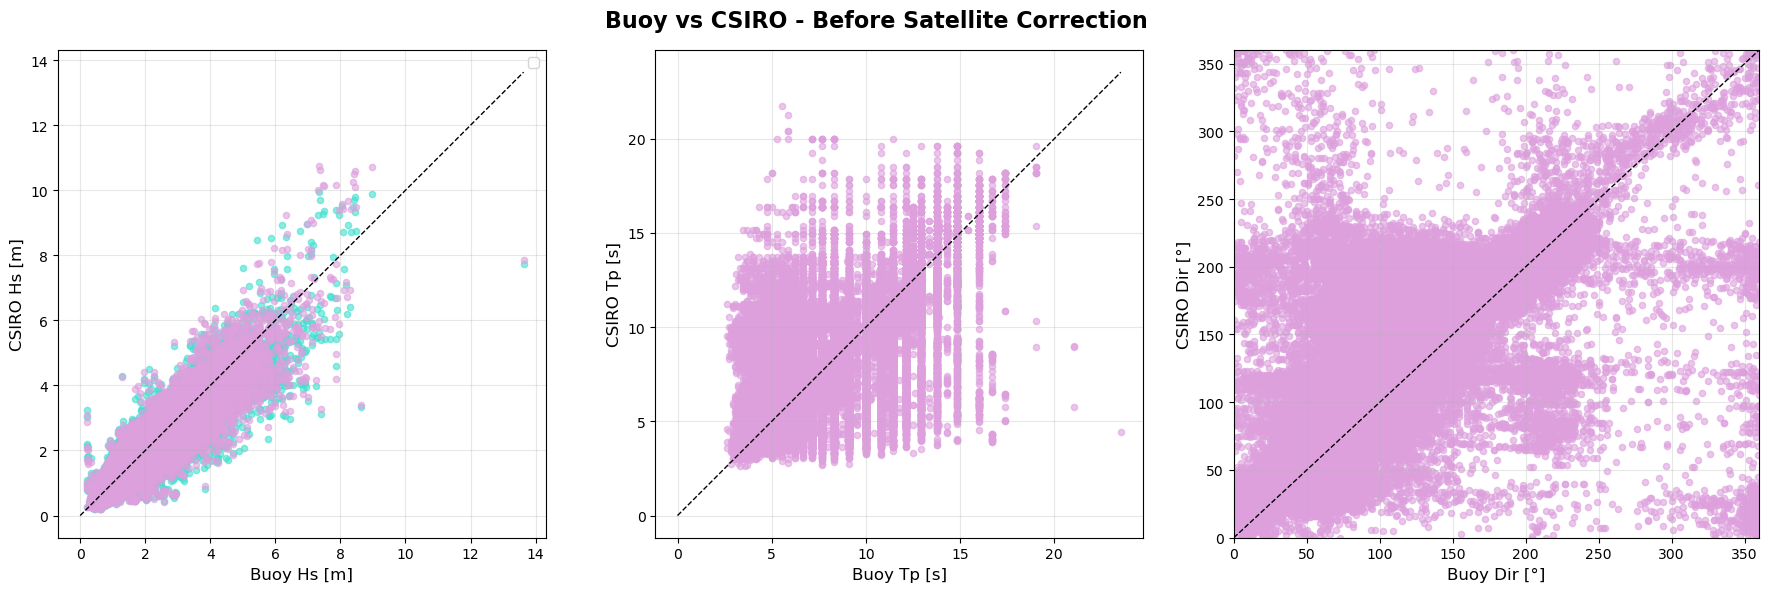

In [25]:
# Find common time range
common_start = max(buoy.index.min(), csiro.index.min())
common_end = min(buoy.index.max(), csiro.index.max())

# Filter data to common time range
buoy_common_ori = buoy[(buoy.index >= common_start) & (buoy.index <= common_end)]
csiro_common_ori = csiro[(csiro.index >= common_start) & (csiro.index <= common_end)]

# Merge data on time index for scatter plots (ADD THIS LINE)
merged_data_ori = buoy_common_ori.merge(csiro_common_ori, left_index=True, right_index=True, how='inner')

# Create scatter plots
fig2, axes = plt.subplots(1, 3, figsize=(18, 6))
fig2.suptitle('Buoy vs CSIRO - Before Satellite Correction', fontsize=16, fontweight='bold')

# Merge data on time index for scatter plots


# Hs scatter plot - USE MERGED DATA INSTEAD
axes[0].scatter(merged_data_ori['Hs_CAL'], merged_data_ori['Hs'], alpha=0.6, s=20, color='turquoise')
axes[0].scatter(buoy_common['Hs_CAL'], csiro_common.sum("part").spec.hs(), alpha=0.6, s=20, color='plum')

axes[0].plot([0, merged_data_ori['Hs_CAL'].max()], [0, merged_data_ori['Hs_CAL'].max()], 'k--', linewidth=1)
axes[0].set_xlabel('Buoy Hs [m]', fontsize=12)
axes[0].set_ylabel('CSIRO Hs [m]', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal')

# Tp scatter plot
axes[1].scatter(merged_data['Tp_Buoy'], merged_data['Tp'], alpha=0.6, s=20, color='plum')
axes[1].plot([0, merged_data['Tp_Buoy'].max()], [0, merged_data['Tp_Buoy'].max()], 'k--', linewidth=1)
axes[1].set_xlabel('Buoy Tp [s]', fontsize=12)
axes[1].set_ylabel('CSIRO Tp [s]', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect('equal')

# Dir scatter plot
axes[2].scatter(merged_data['Dir_Buoy'], merged_data['Dm'], alpha=0.6, s=20, color='plum')
axes[2].plot([0, 360], [0, 360], 'k--', linewidth=1)
axes[2].set_xlabel('Buoy Dir [°]', fontsize=12)
axes[2].set_ylabel('CSIRO Dir [°]', fontsize=12)
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim(0, 360)
axes[2].set_ylim(0, 360)

plt.tight_layout()
plt.show()

In [26]:
full_spec.sum("part").to_netcdf("inputs/41025_spec_WHACS_buoy_correted_15D.nc")